# 🫁 Respiratory Risk Predictor

End-to-end ML analysis of the UCI Exasens respiratory-condition dataset.

> Educational/research use only — not a clinical diagnostic system.

In [15]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [16]:
df = pd.read_csv(r"C:\Users\Lenovo\OneDrive\Desktop\respiratory-risk-predictor\respiratory-risk-predictor\data\Exasens.csv")

df.head()

,Diagnosis,ID,Imaginary Part,Unnamed: 3,Real Part,Unnamed: 5,Gender,Age,Smoking,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Min,Avg.,Min,Avg.,NaN,NaN,NaN,NaN,NaN,Gender,Somking
2,COPD,301-4,-320.61,-300.5635307,-495.26,-464.1719907,1.0,77.0,2.0,NaN,NaN,Male=1,Non-smoker=1
3,COPD,302-3,-325.39,-314.7503595,-473.73,-469.2631404,0.0,72.0,2.0,NaN,NaN,Female=0,Ex-smoker=2
4,COPD,303-3,-323,-317.4360556,-476.12,-471.8976667,1.0,73.0,3.0,NaN,NaN,NaN,Active-smoker=3


In [17]:
print("Shape of dataset:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (401, 13)

Columns:
['Diagnosis', 'ID', 'Imaginary Part', 'Unnamed: 3', 'Real Part', 'Unnamed: 5', 'Gender', 'Age', 'Smoking', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12']

Data types:
Diagnosis             str
ID                    str
Imaginary Part        str
Unnamed: 3            str
Real Part             str
Unnamed: 5            str
Gender            float64
Age               float64
Smoking           float64
Unnamed: 9        float64
Unnamed: 10       float64
Unnamed: 11           str
Unnamed: 12           str
dtype: object


In [18]:
print(df.isnull().sum())

Diagnosis           2
ID                  2
Imaginary Part    300
Unnamed: 3        300
Real Part         300
Unnamed: 5        300
Gender              2
Age                 2
Smoking             2
Unnamed: 9        401
Unnamed: 10       401
Unnamed: 11       398
Unnamed: 12       397
dtype: int64


In [19]:
df.describe(include="all")

,Diagnosis,ID,Imaginary Part,Unnamed: 3,Real Part,Unnamed: 5,Gender,Age,Smoking,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
count,399,399,101,101,101,101,399.000000,399.000000,399.000000,0.0,0.0,3,4
unique,4,399,20,97,28,99,NaN,NaN,NaN,NaN,NaN,3,4
top,HC,301-4,-320.61,-228,-473.73,-442,NaN,NaN,NaN,NaN,NaN,Gender,Somking
freq,160,1,19,2,22,3,NaN,NaN,NaN,NaN,NaN,1,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.398496,48.736842,1.726817,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,0.490203,18.566962,0.742167,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,17.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,31.000000,1.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,49.000000,2.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,64.000000,2.000000,NaN,NaN,NaN,NaN


In [20]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [21]:
missing = df.isnull().sum()

missing = missing[missing > 0]

print(missing)

Diagnosis           2
ID                  2
Imaginary Part    300
Unnamed: 3        300
Real Part         300
Unnamed: 5        300
Gender              2
Age                 2
Smoking             2
Unnamed: 9        401
Unnamed: 10       401
Unnamed: 11       398
Unnamed: 12       397
dtype: int64


In [22]:
display(df.head(10))
display(df.tail(10))

,Diagnosis,ID,Imaginary Part,Unnamed: 3,Real Part,Unnamed: 5,Gender,Age,Smoking,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Min,Avg.,Min,Avg.,NaN,NaN,NaN,NaN,NaN,Gender,Somking
2,COPD,301-4,-320.61,-300.5635307,-495.26,-464.1719907,1.0,77.0,2.0,NaN,NaN,Male=1,Non-smoker=1
3,COPD,302-3,-325.39,-314.7503595,-473.73,-469.2631404,0.0,72.0,2.0,NaN,NaN,Female=0,Ex-smoker=2
4,COPD,303-3,-323,-317.4360556,-476.12,-471.8976667,1.0,73.0,3.0,NaN,NaN,NaN,Active-smoker=3
5,COPD,304-4,-327.78,-317.3996698,-473.73,-468.856388,1.0,76.0,2.0,NaN,NaN,NaN,NaN
6,COPD,305-4,-325.39,-316.1557853,-478.52,-472.8697828,0.0,65.0,2.0,NaN,NaN,NaN,NaN
7,COPD,306-3,-327.78,-318.6775535,-507.23,-469.0241943,1.0,60.0,2.0,NaN,NaN,NaN,NaN
8,COPD,307-3,-330.18,-320.6174777,-473.73,-467.3618538,1.0,76.0,2.0,NaN,NaN,NaN,NaN
9,COPD,308,NaN,NaN,NaN,NaN,1.0,77.0,2.0,NaN,NaN,NaN,NaN


,Diagnosis,ID,Imaginary Part,Unnamed: 3,Real Part,Unnamed: 5,Gender,Age,Smoking,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
391,Infected,I171,NaN,NaN,NaN,NaN,0.0,41.0,2.0,NaN,NaN,NaN,NaN
392,Infected,I172,NaN,NaN,NaN,NaN,0.0,25.0,1.0,NaN,NaN,NaN,NaN
393,Infected,I173,NaN,NaN,NaN,NaN,1.0,27.0,1.0,NaN,NaN,NaN,NaN
394,Infected,I174,NaN,NaN,NaN,NaN,0.0,56.0,3.0,NaN,NaN,NaN,NaN
395,Infected,I175,NaN,NaN,NaN,NaN,0.0,46.0,1.0,NaN,NaN,NaN,NaN
396,Infected,I176,NaN,NaN,NaN,NaN,0.0,49.0,2.0,NaN,NaN,NaN,NaN
397,Infected,I177,NaN,NaN,NaN,NaN,0.0,37.0,1.0,NaN,NaN,NaN,NaN
398,Infected,I178,NaN,NaN,NaN,NaN,0.0,29.0,1.0,NaN,NaN,NaN,NaN
399,Infected,I179,NaN,NaN,NaN,NaN,1.0,51.0,1.0,NaN,NaN,NaN,NaN
400,Infected,I180,NaN,NaN,NaN,NaN,0.0,40.0,1.0,NaN,NaN,NaN,NaN


In [23]:
print(df.dtypes)

Diagnosis             str
ID                    str
Imaginary Part        str
Unnamed: 3            str
Real Part             str
Unnamed: 5            str
Gender            float64
Age               float64
Smoking           float64
Unnamed: 9        float64
Unnamed: 10       float64
Unnamed: 11           str
Unnamed: 12           str
dtype: object


In [24]:
print(df.notna().sum())

Diagnosis         399
ID                399
Imaginary Part    101
Unnamed: 3        101
Real Part         101
Unnamed: 5        101
Gender            399
Age               399
Smoking           399
Unnamed: 9          0
Unnamed: 10         0
Unnamed: 11         3
Unnamed: 12         4
dtype: int64


In [25]:
empty_columns = df.columns[df.isna().all()]

print("Completely empty columns:")
print(empty_columns.tolist())

Completely empty columns:
['Unnamed: 9', 'Unnamed: 10']


In [26]:
for col in df.columns:
    print(f"{col}: {df[col].notna().sum()} non-null values")

Diagnosis: 399 non-null values
ID: 399 non-null values
Imaginary Part: 101 non-null values
Unnamed: 3: 101 non-null values
Real Part: 101 non-null values
Unnamed: 5: 101 non-null values
Gender: 399 non-null values
Age: 399 non-null values
Smoking: 399 non-null values
Unnamed: 9: 0 non-null values
Unnamed: 10: 0 non-null values
Unnamed: 11: 3 non-null values
Unnamed: 12: 4 non-null values


In [27]:
for col in ["Imaginary Part", "Unnamed: 3", "Real Part", "Unnamed: 5", "Unnamed: 11", "Unnamed: 12"]:
    print(f"\n--- {col} ---")
    print(df[col].dropna().head(20).tolist())


--- Imaginary Part ---
['Min ', '-320.61', '-325.39', '-323', '-327.78', '-325.39', '-327.78', '-330.18', '-320.61', '-315.82', '-320.61', '-318.21', '-315.82', '-313.43', '-311.04', '-323', '-308.64', '-325.39', '-323', '-228']

--- Unnamed: 3 ---
['Avg. ', '-300.5635307', '-314.7503595', '-317.4360556', '-317.3996698', '-316.1557853', '-318.6775535', '-320.6174777', '-307.5995856', '-300.104765', '-308.117898', '-306.2530384', '-294.2698616', '-299.0552022', '-297.9901', '-293.0287817', '-294.366142', '-317.1295776', '-314.5167598', '-228']

--- Real Part ---
['Min ', '-495.26', '-473.73', '-476.12', '-473.73', '-478.52', '-507.23', '-473.73', '-476.12', '-473.73', '-471.34', '-471.34', '-471.34', '-521.58', '-466.55', '-466.55', '-468.95', '-473.73', '-502.44', '-442']

--- Unnamed: 5 ---
['Avg. ', '-464.1719907', '-469.2631404', '-471.8976667', '-468.856388', '-472.8697828', '-469.0241943', '-467.3618538', '-470.1816328', '-466.3786343', '-466.13057', '-466.5250462', '-463.1934272

In [28]:
df = df.drop(columns=["Unnamed: 9", "Unnamed: 10"])

print(df.columns.tolist())

['Diagnosis', 'ID', 'Imaginary Part', 'Unnamed: 3', 'Real Part', 'Unnamed: 5', 'Gender', 'Age', 'Smoking', 'Unnamed: 11', 'Unnamed: 12']


In [29]:
print("Unnamed: 11:")
print(df["Unnamed: 11"].dropna().tolist())

print("\nUnnamed: 12:")
print(df["Unnamed: 12"].dropna().tolist())

Unnamed: 11:
['Gender ', 'Male=1', 'Female=0']

Unnamed: 12:
['Somking', 'Non-smoker=1', 'Ex-smoker=2', 'Active-smoker=3']


In [30]:
df = df.drop(columns=["Unnamed: 11", "Unnamed: 12"])

print(df.columns.tolist())

['Diagnosis', 'ID', 'Imaginary Part', 'Unnamed: 3', 'Real Part', 'Unnamed: 5', 'Gender', 'Age', 'Smoking']


In [31]:
print("Shape:", df.shape)
display(df.head())

Shape: (401, 9)


,Diagnosis,ID,Imaginary Part,Unnamed: 3,Real Part,Unnamed: 5,Gender,Age,Smoking
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Min,Avg.,Min,Avg.,NaN,NaN,NaN
2,COPD,301-4,-320.61,-300.5635307,-495.26,-464.1719907,1.0,77.0,2.0
3,COPD,302-3,-325.39,-314.7503595,-473.73,-469.2631404,0.0,72.0,2.0
4,COPD,303-3,-323,-317.4360556,-476.12,-471.8976667,1.0,73.0,3.0


In [32]:
for col in ["Imaginary Part", "Unnamed: 3", "Real Part", "Unnamed: 5"]:
    print(f"\n--- {col} ---")
    display(df[col].dropna().head(15))


--- Imaginary Part ---


1        Min 
2     -320.61
3     -325.39
4        -323
5     -327.78
6     -325.39
7     -327.78
8     -330.18
10    -320.61
11    -315.82
12    -320.61
13    -318.21
14    -315.82
15    -313.43
16    -311.04
Name: Imaginary Part, dtype: str


--- Unnamed: 3 ---


1            Avg. 
2     -300.5635307
3     -314.7503595
4     -317.4360556
5     -317.3996698
6     -316.1557853
7     -318.6775535
8     -320.6174777
10    -307.5995856
11     -300.104765
12     -308.117898
13    -306.2530384
14    -294.2698616
15    -299.0552022
16       -297.9901
Name: Unnamed: 3, dtype: str


--- Real Part ---


1        Min 
2     -495.26
3     -473.73
4     -476.12
5     -473.73
6     -478.52
7     -507.23
8     -473.73
10    -476.12
11    -473.73
12    -471.34
13    -471.34
14    -471.34
15    -521.58
16    -466.55
Name: Real Part, dtype: str


--- Unnamed: 5 ---


1            Avg. 
2     -464.1719907
3     -469.2631404
4     -471.8976667
5      -468.856388
6     -472.8697828
7     -469.0241943
8     -467.3618538
10    -470.1816328
11    -466.3786343
12      -466.13057
13    -466.5250462
14    -463.1934272
15    -421.1894102
16    -428.9503667
Name: Unnamed: 5, dtype: str

In [33]:
display(df.iloc[:5])

,Diagnosis,ID,Imaginary Part,Unnamed: 3,Real Part,Unnamed: 5,Gender,Age,Smoking
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,Min,Avg.,Min,Avg.,NaN,NaN,NaN
2,COPD,301-4,-320.61,-300.5635307,-495.26,-464.1719907,1.0,77.0,2.0
3,COPD,302-3,-325.39,-314.7503595,-473.73,-469.2631404,0.0,72.0,2.0
4,COPD,303-3,-323,-317.4360556,-476.12,-471.8976667,1.0,73.0,3.0


In [34]:
display(df[["Diagnosis", "ID"]].head(15))

,Diagnosis,ID
0,NaN,NaN
1,NaN,NaN
2,COPD,301-4
3,COPD,302-3
4,COPD,303-3
5,COPD,304-4
6,COPD,305-4
7,COPD,306-3
8,COPD,307-3
9,COPD,308


In [35]:
for col in ["Imaginary Part", "Unnamed: 3", "Real Part", "Unnamed: 5"]:
    print(f"\n{col}")
    print(df[df[col].isin(["Min", "Avg."])].index.tolist())


Imaginary Part
[]

Unnamed: 3
[]

Real Part
[]

Unnamed: 5
[]


In [36]:
display(df.iloc[1])

Diagnosis           NaN
ID                  NaN
Imaginary Part     Min 
Unnamed: 3        Avg. 
Real Part          Min 
Unnamed: 5        Avg. 
Gender              NaN
Age                 NaN
Smoking             NaN
Name: 1, dtype: object

In [37]:
df = df.drop(index=[0, 1]).reset_index(drop=True)

print("New shape:", df.shape)
display(df.head())

New shape: (399, 9)


,Diagnosis,ID,Imaginary Part,Unnamed: 3,Real Part,Unnamed: 5,Gender,Age,Smoking
0,COPD,301-4,-320.61,-300.5635307,-495.26,-464.1719907,1.0,77.0,2.0
1,COPD,302-3,-325.39,-314.7503595,-473.73,-469.2631404,0.0,72.0,2.0
2,COPD,303-3,-323,-317.4360556,-476.12,-471.8976667,1.0,73.0,3.0
3,COPD,304-4,-327.78,-317.3996698,-473.73,-468.856388,1.0,76.0,2.0
4,COPD,305-4,-325.39,-316.1557853,-478.52,-472.8697828,0.0,65.0,2.0


In [38]:
df = df.rename(columns={
    "Unnamed: 3": "Imaginary Part Avg",
    "Unnamed: 5": "Real Part Avg"
})

print(df.columns.tolist())

['Diagnosis', 'ID', 'Imaginary Part', 'Imaginary Part Avg', 'Real Part', 'Real Part Avg', 'Gender', 'Age', 'Smoking']


In [39]:
display(df.head())
print("\nShape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

,Diagnosis,ID,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg,Gender,Age,Smoking
0,COPD,301-4,-320.61,-300.5635307,-495.26,-464.1719907,1.0,77.0,2.0
1,COPD,302-3,-325.39,-314.7503595,-473.73,-469.2631404,0.0,72.0,2.0
2,COPD,303-3,-323,-317.4360556,-476.12,-471.8976667,1.0,73.0,3.0
3,COPD,304-4,-327.78,-317.3996698,-473.73,-468.856388,1.0,76.0,2.0
4,COPD,305-4,-325.39,-316.1557853,-478.52,-472.8697828,0.0,65.0,2.0



Shape: (399, 9)

Missing values:
Diagnosis               0
ID                      0
Imaginary Part        299
Imaginary Part Avg    299
Real Part             299
Real Part Avg         299
Gender                  0
Age                     0
Smoking                 0
dtype: int64


In [40]:
print(df["Diagnosis"].value_counts())

Diagnosis
HC          160
Asthma       80
Infected     80
COPD         79
Name: count, dtype: int64


In [41]:
df["Signal_Missing"] = df["Imaginary Part"].isna()

print(
    df.groupby("Diagnosis")["Signal_Missing"]
      .value_counts()
)

Diagnosis  Signal_Missing
Asthma     True               70
           False              10
COPD       False              40
           True               39
HC         True              120
           False              40
Infected   True               70
           False              10
Name: count, dtype: int64


In [42]:
signal_data = df[df["Imaginary Part"].notna()]

print("Rows with signal data:", len(signal_data))
print("\nDiagnosis distribution:")
print(signal_data["Diagnosis"].value_counts())

Rows with signal data: 100

Diagnosis distribution:
Diagnosis
COPD        40
HC          40
Asthma      10
Infected    10
Name: count, dtype: int64


In [43]:
df = df.drop(columns=["Signal_Missing"])

print(df.columns.tolist())

['Diagnosis', 'ID', 'Imaginary Part', 'Imaginary Part Avg', 'Real Part', 'Real Part Avg', 'Gender', 'Age', 'Smoking']


In [44]:
print(df[[
    "Gender",
    "Age",
    "Smoking"
]].describe())

print("\nUnique values:")

for col in ["Gender", "Smoking"]:
    print(f"{col}:", sorted(df[col].dropna().unique()))

           Gender         Age     Smoking
count  399.000000  399.000000  399.000000
mean     0.398496   48.736842    1.726817
std      0.490203   18.566962    0.742167
min      0.000000   17.000000    1.000000
25%      0.000000   31.000000    1.000000
50%      0.000000   49.000000    2.000000
75%      1.000000   64.000000    2.000000
max      1.000000   93.000000    3.000000

Unique values:
Gender: [np.float64(0.0), np.float64(1.0)]
Smoking: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]


In [45]:
print("Age range:")
print("Min:", df["Age"].min())
print("Max:", df["Age"].max())

display(df["Age"].describe())

Age range:
Min: 17.0
Max: 93.0


count    399.000000
mean      48.736842
std       18.566962
min       17.000000
25%       31.000000
50%       49.000000
75%       64.000000
max       93.000000
Name: Age, dtype: float64

In [46]:
X = df[["Gender", "Age", "Smoking"]]
y = df["Diagnosis"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (399, 3)
y shape: (399,)

Target distribution:
Diagnosis
HC          160
Asthma       80
Infected     80
COPD         79
Name: count, dtype: int64


In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (319, 3)
X_test: (80, 3)
y_train: (319,)
y_test: (80,)


In [48]:
print("Training set:")
print(y_train.value_counts())

print("\nTesting set:")
print(y_test.value_counts())

Training set:
Diagnosis
HC          128
Asthma       64
Infected     64
COPD         63
Name: count, dtype: int64

Testing set:
Diagnosis
HC          32
COPD        16
Infected    16
Asthma      16
Name: count, dtype: int64


In [49]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (319, 3)
X_test_scaled shape: (80, 3)


In [50]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [51]:
y_pred_lr = logistic_model.predict(X_test_scaled)

print("Predictions:")
print(y_pred_lr)

Predictions:
['HC' 'HC' 'Asthma' 'HC' 'HC' 'Asthma' 'HC' 'HC' 'HC' 'HC' 'COPD' 'COPD'
 'HC' 'COPD' 'HC' 'HC' 'HC' 'COPD' 'HC' 'Asthma' 'HC' 'HC' 'HC' 'HC' 'HC'
 'HC' 'Asthma' 'HC' 'COPD' 'HC' 'HC' 'COPD' 'HC' 'HC' 'Asthma' 'HC' 'COPD'
 'HC' 'COPD' 'COPD' 'HC' 'HC' 'COPD' 'HC' 'Asthma' 'COPD' 'COPD' 'HC' 'HC'
 'HC' 'HC' 'Asthma' 'HC' 'COPD' 'Asthma' 'HC' 'HC' 'HC' 'HC' 'HC' 'COPD'
 'Asthma' 'HC' 'HC' 'HC' 'HC' 'HC' 'COPD' 'Asthma' 'HC' 'HC' 'COPD' 'HC'
 'HC' 'COPD' 'COPD' 'Asthma' 'COPD' 'HC' 'HC']


In [52]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average="weighted")
recall_lr = recall_score(y_test, y_pred_lr, average="weighted")
f1_lr = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1-Score :", f1_lr)

Logistic Regression Results
---------------------------
Accuracy : 0.575
Precision: 0.4517511961722488
Recall   : 0.575
F1-Score : 0.49581623435281974


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [53]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

      Asthma       0.45      0.31      0.37        16
        COPD       0.68      0.81      0.74        16
          HC       0.56      0.88      0.68        32
    Infected       0.00      0.00      0.00        16

    accuracy                           0.57        80
   macro avg       0.42      0.50      0.45        80
weighted avg       0.45      0.57      0.50        80



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_c

In [54]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

      Asthma       0.45      0.31      0.37        16
        COPD       0.68      0.81      0.74        16
          HC       0.56      0.88      0.68        32
    Infected       0.00      0.00      0.00        16

    accuracy                           0.57        80
   macro avg       0.42      0.50      0.45        80
weighted avg       0.45      0.57      0.50        80



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_c

In [55]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[ 5  5  6  0]
 [ 2 13  1  0]
 [ 3  1 28  0]
 [ 1  0 15  0]]


In [56]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [57]:
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Predictions:")
print(y_pred_rf)

Random Forest Predictions:
['HC' 'Infected' 'COPD' 'HC' 'HC' 'Asthma' 'HC' 'Infected' 'Infected'
 'Infected' 'COPD' 'COPD' 'Asthma' 'COPD' 'Infected' 'Infected' 'Asthma'
 'COPD' 'HC' 'COPD' 'HC' 'HC' 'Asthma' 'Infected' 'HC' 'Asthma' 'Asthma'
 'Infected' 'COPD' 'HC' 'Infected' 'COPD' 'HC' 'Infected' 'HC' 'HC'
 'Infected' 'HC' 'Asthma' 'COPD' 'Asthma' 'Infected' 'COPD' 'Infected'
 'HC' 'Asthma' 'Asthma' 'Infected' 'HC' 'Infected' 'Infected' 'COPD' 'HC'
 'COPD' 'Asthma' 'HC' 'HC' 'HC' 'Infected' 'Infected' 'COPD' 'COPD' 'HC'
 'Infected' 'Asthma' 'Infected' 'Asthma' 'Asthma' 'Asthma' 'HC' 'Infected'
 'COPD' 'Asthma' 'Asthma' 'COPD' 'COPD' 'COPD' 'COPD' 'HC' 'Infected']


In [58]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)
recall_rf = recall_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)
f1_rf = f1_score(
    y_test, y_pred_rf, average="weighted", zero_division=0
)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-Score :", f1_rf)

Random Forest Results
---------------------
Accuracy : 0.3875
Precision: 0.3919223191669012
Recall   : 0.3875
F1-Score : 0.38351737930685303


In [59]:
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))

              precision    recall  f1-score   support

      Asthma       0.41      0.44      0.42        16
        COPD       0.68      0.81      0.74        16
          HC       0.36      0.25      0.30        32
    Infected       0.14      0.19      0.16        16

    accuracy                           0.39        80
   macro avg       0.40      0.42      0.41        80
weighted avg       0.39      0.39      0.38        80



In [60]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[ 7  4  3  2]
 [ 3 13  0  0]
 [ 5  2  8 17]
 [ 2  0 11  3]]


In [61]:
signal_cols = [
    "Imaginary Part",
    "Imaginary Part Avg",
    "Real Part",
    "Real Part Avg"
]

print(df[signal_cols].dtypes)

display(df[signal_cols].describe())

Imaginary Part        str
Imaginary Part Avg    str
Real Part             str
Real Part Avg         str
dtype: object


,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
count,100,100,100,100
unique,19,96,27,98
top,-320.61,-228,-473.73,-442
freq,19,2,22,3


In [62]:
for col in signal_cols:
    non_numeric = pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna()
    
    print(f"\n{col}")
    print("Non-numeric values:")
    print(df.loc[non_numeric, col].unique())


Imaginary Part
Non-numeric values:
<ArrowStringArray>
[]
Length: 0, dtype: str

Imaginary Part Avg
Non-numeric values:
<ArrowStringArray>
[]
Length: 0, dtype: str

Real Part
Non-numeric values:
<ArrowStringArray>
[]
Length: 0, dtype: str

Real Part Avg
Non-numeric values:
<ArrowStringArray>
[]
Length: 0, dtype: str


In [63]:
for col in signal_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print(df[signal_cols].dtypes)

Imaginary Part        float64
Imaginary Part Avg    float64
Real Part             float64
Real Part Avg         float64
dtype: object


In [64]:
print("Missing values after conversion:")

print(df[signal_cols].isnull().sum())

Missing values after conversion:
Imaginary Part        299
Imaginary Part Avg    299
Real Part             299
Real Part Avg         299
dtype: int64


In [65]:
signal_data = df[df[signal_cols].notna().all(axis=1)].copy()

print("Signal dataset shape:", signal_data.shape)

print("\nDiagnosis distribution:")
print(signal_data["Diagnosis"].value_counts())

display(signal_data[[
    "Diagnosis",
    "Imaginary Part",
    "Imaginary Part Avg",
    "Real Part",
    "Real Part Avg"
]].head(10))

Signal dataset shape: (100, 9)

Diagnosis distribution:
Diagnosis
COPD        40
HC          40
Asthma      10
Infected    10
Name: count, dtype: int64


,Diagnosis,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
0,COPD,-320.61,-300.563531,-495.26,-464.171991
1,COPD,-325.39,-314.750360,-473.73,-469.263140
2,COPD,-323.00,-317.436056,-476.12,-471.897667
3,COPD,-327.78,-317.399670,-473.73,-468.856388
4,COPD,-325.39,-316.155785,-478.52,-472.869783
5,COPD,-327.78,-318.677553,-507.23,-469.024194
6,COPD,-330.18,-320.617478,-473.73,-467.361854
8,COPD,-320.61,-307.599586,-476.12,-470.181633
9,COPD,-315.82,-300.104765,-473.73,-466.378634
10,COPD,-320.61,-308.117898,-471.34,-466.130570


In [66]:
signal_cols = [
    "Imaginary Part",
    "Imaginary Part Avg",
    "Real Part",
    "Real Part Avg"
]

signal_data.groupby("Diagnosis")[signal_cols].mean()

,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
Diagnosis,,,,
Asthma,-323.00000,-313.717073,-473.7320,-468.770152
COPD,-312.27575,-302.079113,-473.1735,-460.042921
HC,-313.45925,-302.805171,-471.7490,-451.847266
Infected,-323.47800,-314.542555,-476.6000,-470.685761


In [67]:
signal_data.groupby("Diagnosis")[signal_cols].median()

,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
Diagnosis,,,,
Asthma,-320.61,-312.022056,-473.73,-469.329893
COPD,-323.00,-314.504454,-473.73,-466.412490
HC,-323.00,-314.623387,-473.73,-465.142229
Infected,-323.00,-313.590142,-476.12,-472.263719


In [68]:
for diagnosis in signal_data["Diagnosis"].unique():
    print(f"\n===== {diagnosis} =====")
    display(signal_data[signal_data["Diagnosis"] == diagnosis][signal_cols].describe())


===== COPD =====


,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
count,40.000000,40.000000,40.000000,40.000000
mean,-312.275750,-302.079113,-473.173500,-460.042921
std,32.559147,29.362806,16.772031,15.212873
min,-337.350000,-327.895087,-521.580000,-472.869783
25%,-327.780000,-318.128593,-476.120000,-469.083931
50%,-323.000000,-314.504454,-473.730000,-466.412490
75%,-317.612500,-299.842374,-470.742500,-462.166809
max,-225.000000,-225.000000,-441.000000,-414.675667



===== HC =====


,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
count,40.000000,40.000000,40.000000,40.000000
mean,-313.459250,-302.805171,-471.749000,-451.847266
std,30.672563,27.775900,76.210319,67.096213
min,-337.350000,-328.280985,-626.860000,-473.928698
25%,-327.780000,-318.884909,-494.665000,-468.716809
50%,-323.000000,-314.623387,-473.730000,-465.142229
75%,-320.010000,-302.325191,-468.350000,-459.326848
max,-234.000000,-234.000000,-44.000000,-44.000000



===== Asthma =====


,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
count,10.00000,10.000000,10.000000,10.000000
mean,-323.00000,-313.717073,-473.732000,-468.770152
std,3.37997,2.706223,2.984418,2.737492
min,-327.78000,-318.446700,-478.520000,-473.180280
25%,-326.58500,-315.032366,-473.730000,-470.600430
50%,-320.61000,-312.022056,-473.730000,-469.329893
75%,-320.61000,-311.910284,-471.937500,-467.277195
max,-320.61000,-311.658041,-468.950000,-464.140266



===== Infected =====


,Imaginary Part,Imaginary Part Avg,Real Part,Real Part Avg
count,10.000000,10.000000,10.000000,10.000000
mean,-323.478000,-314.542555,-476.600000,-470.685761
std,3.146581,3.248253,1.888921,4.830766
min,-327.780000,-319.555285,-480.910000,-473.088617
25%,-326.585000,-317.147482,-476.120000,-472.373317
50%,-323.000000,-313.590142,-476.120000,-472.263719
75%,-320.610000,-311.856249,-476.120000,-471.858611
max,-320.610000,-311.423617,-473.730000,-457.046465


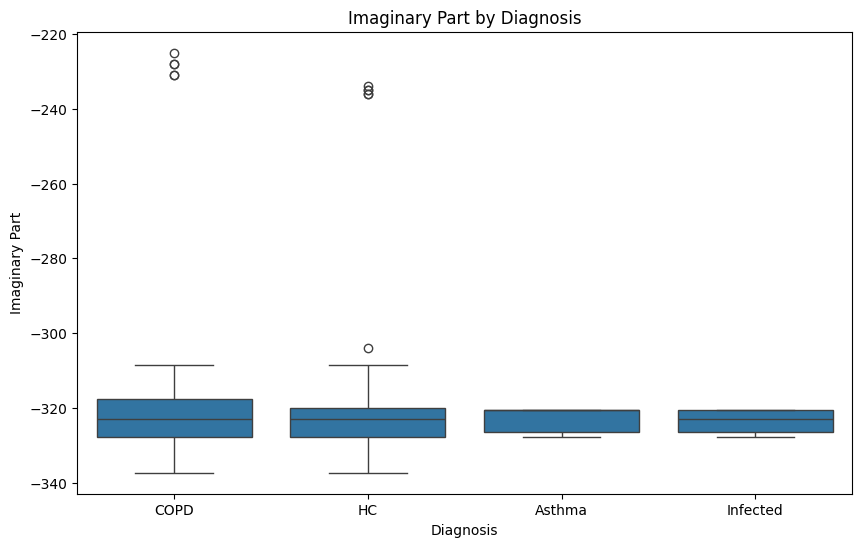

In [69]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=signal_data,
    x="Diagnosis",
    y="Imaginary Part"
)

plt.title("Imaginary Part by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Imaginary Part")
plt.show()

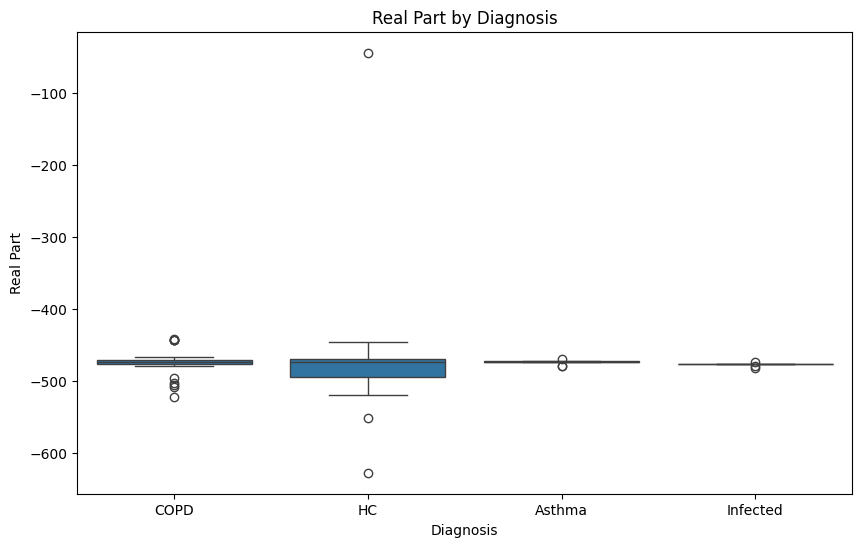

In [70]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=signal_data,
    x="Diagnosis",
    y="Real Part"
)

plt.title("Real Part by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Real Part")
plt.show()

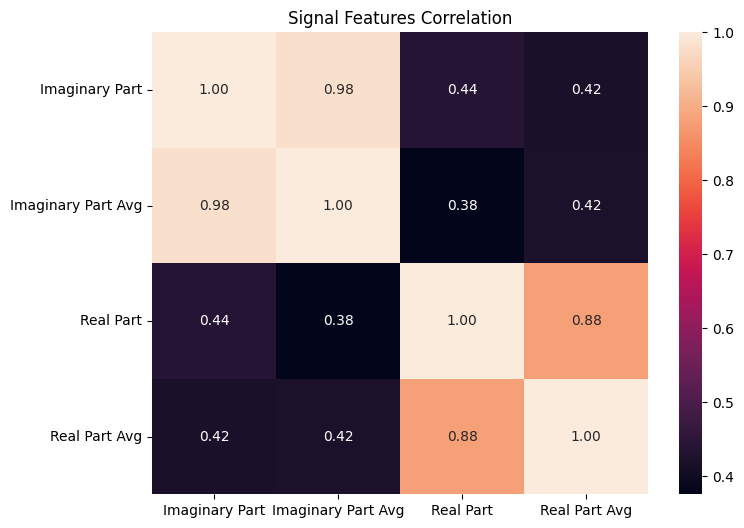

In [71]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    signal_data[signal_cols].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Signal Features Correlation")
plt.show()

In [72]:
signal_cols = [
    "Imaginary Part",
    "Imaginary Part Avg",
    "Real Part",
    "Real Part Avg"
]

signal_data = df.dropna(subset=signal_cols).copy()

X_signal = signal_data[signal_cols]
y_signal = signal_data["Diagnosis"]

print("X_signal shape:", X_signal.shape)
print("y_signal shape:", y_signal.shape)

print("\nDiagnosis distribution:")
print(y_signal.value_counts())

X_signal shape: (100, 4)
y_signal shape: (100,)

Diagnosis distribution:
Diagnosis
COPD        40
HC          40
Asthma      10
Infected    10
Name: count, dtype: int64


In [76]:
X_train_signal, X_test_signal, y_train_signal, y_test_signal = train_test_split(
    X_signal,
    y_signal,
    test_size=0.2,
    random_state=42,
    stratify=y_signal
)

print("Training:", X_train_signal.shape)
print("Testing :", X_test_signal.shape)

Training: (80, 4)
Testing : (20, 4)


In [74]:
signal_scaler = StandardScaler()

X_train_signal_scaled = signal_scaler.fit_transform(X_train_signal)
X_test_signal_scaled = signal_scaler.transform(X_test_signal)

signal_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

signal_lr.fit(X_train_signal_scaled, y_train_signal)

y_pred_signal_lr = signal_lr.predict(X_test_signal_scaled)

print(classification_report(
    y_test_signal,
    y_pred_signal_lr,
    zero_division=0
))

              precision    recall  f1-score   support

      Asthma       0.00      0.00      0.00         2
        COPD       0.50      0.25      0.33         8
          HC       0.67      0.25      0.36         8
    Infected       0.25      1.00      0.40         2

    accuracy                           0.30        20
   macro avg       0.35      0.38      0.27        20
weighted avg       0.49      0.30      0.32        20



In [75]:
cm_signal = confusion_matrix(
    y_test_signal,
    y_pred_signal_lr
)

print(cm_signal)

[[0 0 0 2]
 [3 2 1 2]
 [2 2 2 2]
 [0 0 0 2]]


In [77]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Signal Logistic Regression"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf,
        accuracy_score(y_test_signal, y_pred_signal_lr)
    ],
    "Weighted F1": [
        f1_lr,
        f1_rf,
        f1_score(
            y_test_signal,
            y_pred_signal_lr,
            average="weighted",
            zero_division=0
        )
    ]
})

display(comparison)

,Model,Accuracy,Weighted F1
0,Logistic Regression,0.5750,0.495816
1,Random Forest,0.3875,0.383517
2,Signal Logistic Regression,0.3000,0.318788


In [78]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
1,Age,0.838993
2,Smoking,0.102405
0,Gender,0.058602


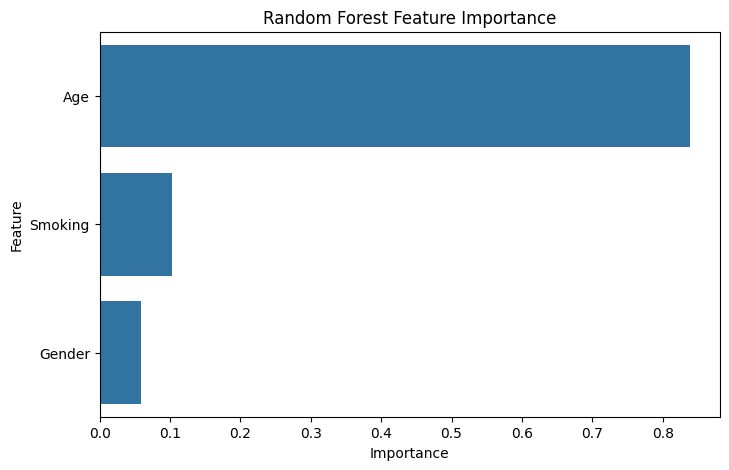

In [79]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [80]:
best_model = logistic_model

print("Best Model: Logistic Regression")
print(f"Accuracy: {accuracy_lr:.2%}")
print(f"Weighted F1-Score: {f1_lr:.2%}")

Best Model: Logistic Regression
Accuracy: 57.50%
Weighted F1-Score: 49.58%


In [81]:
import joblib

joblib.dump(best_model, "respiratory_risk_logistic_model.pkl")
joblib.dump(scaler, "respiratory_risk_scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [82]:
new_patient = pd.DataFrame({
    "Gender": [1],
    "Age": [50],
    "Smoking": [2]
})

new_patient_scaled = scaler.transform(new_patient)

prediction = best_model.predict(new_patient_scaled)

print("Predicted Diagnosis:", prediction[0])

Predicted Diagnosis: HC


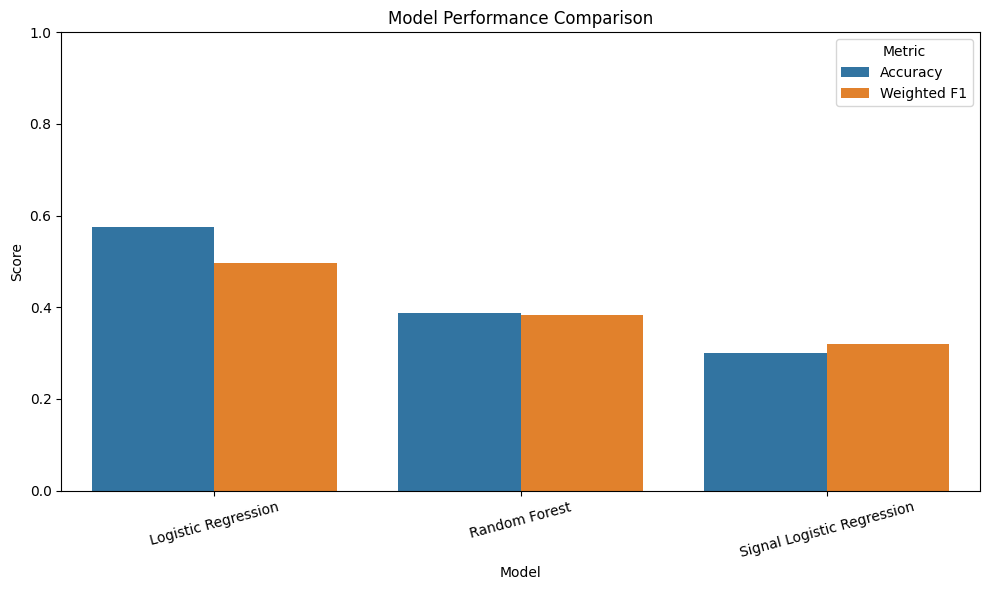

In [83]:
comparison_plot = comparison.copy()

comparison_plot = comparison_plot.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Weighted F1"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

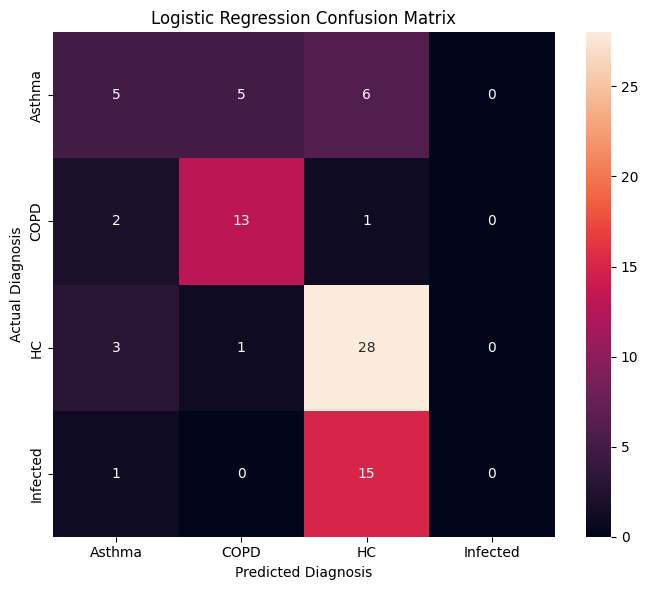

In [84]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt="d",
    xticklabels=logistic_model.classes_,
    yticklabels=logistic_model.classes_
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

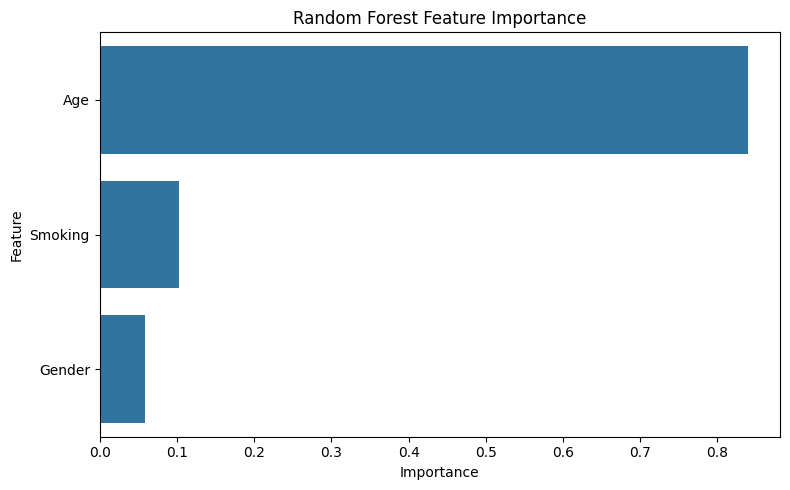

In [85]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [86]:
print("=" * 50)
print("FINAL MODEL RESULTS")
print("=" * 50)

print(f"Best Model       : Logistic Regression")
print(f"Accuracy         : {accuracy_lr:.2%}")
print(f"Weighted F1      : {f1_lr:.2%}")

print("\nModel saved successfully:")
print("respiratory_risk_logistic_model.pkl")
print("respiratory_risk_scaler.pkl")

FINAL MODEL RESULTS
Best Model       : Logistic Regression
Accuracy         : 57.50%
Weighted F1      : 49.58%

Model saved successfully:
respiratory_risk_logistic_model.pkl
respiratory_risk_scaler.pkl
